In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import os
import sys

# для colab способ 1
# from google.colab import drive
# drive.mount('/content/drive')
# import shutil
# shutil.copy('/content/drive/MyDrive/model.py', '/content/model.py')

# для colab способ 2
# from google.colab import drive
# drive.mount('/content/drive')
# sys.path.append('/content/drive/MyDrive')

from model import SASRecModel, negative_sampling_loss

In [2]:
def ndcg_at_k(rel, pred, k=10):
    ndcg = 0.0
    if rel in pred[:k]:
        pred_list = list(pred[:k])
        score = pred_list.index(rel) + 1
        ndcg = 1.0 / np.log2(score + 1)
        return ndcg
    return ndcg

def recall_at_k(rel, pred, k=10):
    recall = 1.0 if rel in pred[:k] else 0.0
    return recall

In [3]:
def filter_by_threshold(df, listen_threshold=50):
    filtered_rows = []
    for _, row in df.iterrows():
        items = np.array(row['item_id'])
        ratios = np.array(row['played_ratio_pct'])
        mask = ratios >= listen_threshold
        if mask.any():
            filtered_rows.append({
                'uid': row['uid'],
                'item_id': items[mask].tolist(),
                'played_ratio_pct': ratios[mask].tolist(),
                'timestamp': np.array(row['timestamp'])[mask].tolist()
            })
    print(f'После фильтрации: {len(filtered_rows)} пользователей')
    data_filter = pd.DataFrame(filtered_rows)
    return data_filter

In [4]:
def create_track_index(df):
    all_items = set()
    for items in df['item_id']:
        all_items.update(items)
    track_to_index = {item: i+1 for i, item in enumerate(sorted(all_items))}
    print(f'Уникальных треков: {len(track_to_index)}')
    return track_to_index

In [5]:
def flatten_events(df):
    all_events = []
    for _, row in df.iterrows():
        uid = row['uid']
        for item, ts, ratio in zip(row['item_id'], row['timestamp'], row['played_ratio_pct']):
            all_events.append({'uid': uid, 'item_id': item, 'timestamp': ts, 'played_ratio_pct': ratio})
    print(f'Всего событий: {len(all_events)}')
    return all_events

In [6]:
def split_by_time(all_events, train_ratio=0.8, val_ratio=0.1):
    all_events = sorted(all_events, key=lambda x: x['timestamp'])
    total_sec = all_events[-1]['timestamp'] - all_events[0]['timestamp']
    print(f'Диапазон по времени: {total_sec/(24*3600):.0f} дней')
    train_cut_off = all_events[0]['timestamp'] + total_sec * train_ratio
    val_cut_off = train_cut_off + total_sec * val_ratio
    train_events = [e for e in all_events if e['timestamp'] <= train_cut_off]
    validate_events = [e for e in all_events if train_cut_off < e['timestamp'] <= val_cut_off]
    test_events = [e for e in all_events if e['timestamp'] > val_cut_off]
    train_users = set(e['uid'] for e in train_events)
    validate_events = [e for e in validate_events if e['uid'] in train_users]
    test_events = [e for e in test_events if e['uid'] in train_users]
    print(f'Train: {len(train_events)}, Validate: {len(validate_events)}, Test: {len(test_events)}')
    return train_events, validate_events, test_events

In [7]:
def events_to_tensors(events, track_to_index, max_seq_len=50):
    user_sequences = defaultdict(lambda: {'items': [], 'ratios': []})
    for i in tqdm(events, desc='Группировка по пользователям'):
        user_sequences[i['uid']]['items'].append(i['item_id'])
        user_sequences[i['uid']]['ratios'].append(i['played_ratio_pct'])

    print(f'Пользователей: {len(user_sequences)}')

    inputs, targets, weights = [], [], []
    for uid, seq in tqdm(user_sequences.items(), desc='Создание примеров'):
        items = seq['items']
        ratios = seq['ratios']
        for i in range(1, len(items)):
            history = items[max(0, i-max_seq_len):i]
            padded = [0] * (max_seq_len - len(history)) + history
            mapped = [track_to_index.get(item, 0) for item in padded]
            inputs.append(mapped)
            targets.append(track_to_index.get(items[i], 0))
            weights.append(min(ratios[i]/100.0, 1.0))

    print(f'Примеров: {len(inputs)}')
    return (torch.tensor(inputs, dtype=torch.long),
            torch.tensor(targets, dtype=torch.long),
            torch.tensor(weights, dtype=torch.float32))

In [8]:
url = "https://huggingface.co/datasets/yandex/yambda/resolve/main/sequential/50m/listens.parquet"
df = pd.read_parquet(url)

In [9]:
df_filtered = filter_by_threshold(df)
track_to_index = create_track_index(df_filtered)
all_events = flatten_events(df_filtered)
train_events, validate_events, test_events = split_by_time(all_events)

После фильтрации: 9209 пользователей
Уникальных треков: 631003
Всего событий: 29439278
Диапазон по времени: 301 дней
Train: 21684895, Validate: 3549894, Test: 3672331


In [10]:
train_inputs, train_targets, train_weights = events_to_tensors(train_events, track_to_index)
validate_inputs, validate_targets, validate_weights = events_to_tensors(validate_events, track_to_index)
test_inputs, test_targets, test_weights = events_to_tensors(test_events, track_to_index)

Группировка по пользователям: 100%|██████████| 21684895/21684895 [00:09<00:00, 2207990.45it/s]


Пользователей: 8303


Создание примеров: 100%|██████████| 8303/8303 [03:12<00:00, 43.22it/s]  


Примеров: 21676592


Группировка по пользователям: 100%|██████████| 3549894/3549894 [00:06<00:00, 512762.56it/s] 


...

Примеров: 3542362


Группировка по пользователям: 100%|██████████| 3672331/3672331 [00:02<00:00, 1544719.99it/s]


Пользователей: 8092


Создание примеров: 100%|██████████| 8092/8092 [00:24<00:00, 334.38it/s] 


Примеров: 3664239


In [11]:
print(f'Train примеров до обрезки {len(train_inputs)}')
max_samp = 500000
if len(train_inputs) > max_samp:
    idx = torch.randperm(len(train_inputs))[:max_samp]
    train_inputs = train_inputs[idx]
    train_targets = train_targets[idx]
    train_weights = train_weights[idx]
    print(f'Обрезано до {max_samp} примеров')

print(f'Train примеров до обрезки {len(validate_inputs)}')
max_samp1 = 50000
if len(validate_inputs) > max_samp1:
    idx = torch.randperm(len(train_inputs))[:max_samp1]
    validate_inputs = validate_inputs[idx]
    validate_targets = validate_targets[idx]
    print(f'Обрезано до {max_samp1} примеров')

Train примеров до обрезки 21676592
Обрезано до 500000 примеров
Train примеров до обрезки 3542362
Обрезано до 50000 примеров


In [12]:
cnt_item = len(track_to_index)
print(f'\nTrain: {train_inputs.shape}, Val: {validate_inputs.shape}, Test: {test_inputs.shape}')


Train: torch.Size([500000, 50]), Val: torch.Size([50000, 50]), Test: torch.Size([3664239, 50])


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

batch_size = 32
train_dataset = TensorDataset(train_inputs, train_targets, train_weights)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          pin_memory=True)

model = SASRecModel(cnt_item=cnt_item).to(device)
print(f'Параметров: {sum(p.numel() for p in model.parameters()):,}')

Device: cuda
Параметров: 81,502,940


In [14]:
def check_metrics_validate(model, validate_inputs, validate_targets, k=10, batch_size=16):
    model.eval()
    ndcg_scores, recall_scores = [], []
    with torch.no_grad():
        for i in tqdm(range(0, len(validate_inputs), batch_size), desc="Validate"):
            batch_input = validate_inputs[i:i+batch_size].to(device)
            batch_target = validate_targets[i:i+batch_size]
            logits = model(batch_input)
            scores = logits[:, -1, :]
            _, pred = torch.topk(scores, k=k, dim=1)
            pred = pred.cpu().numpy()
            for j in range(len(batch_target)):
                target = batch_target[j].item()
                ndcg_scores.append(ndcg_at_k(target, pred[j], k))
                recall_scores.append(recall_at_k(target, pred[j], k))
    model.train()
    return np.mean(ndcg_scores), np.mean(recall_scores)

In [15]:
from torch.amp import GradScaler, autocast
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scaler = GradScaler('cuda')
os.makedirs('checkpoints', exist_ok=True)

best_ndcg = 0.0
patience = 2
patience_counter = 0

history = {'epoch': [], 'train_loss': [], 'validate_ndcg': [], 'validate_recall': []}

for epoch in range(1, 13):
    model.train()
    total_loss = 0
    for inputs, targets, weights in tqdm(train_loader, desc=f"Epoch {epoch}/12"):
        inputs, targets, weights = inputs.to(device), targets.to(device), weights.to(device)
        with autocast('cuda'):
            logits = model(inputs)
            loss = negative_sampling_loss(logits[:, -1, :], targets, weights, cnt_item)

        optimizer.zero_grad()
        scaler.scale(loss).backward()   # масштабируем loss для устойчивости
        scaler.step(optimizer)          # шаг оптимизатора
        scaler.update()                 # обновляем scaler

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    history['epoch'].append(epoch)
    history['train_loss'].append(avg_loss)

    if epoch % 2 == 0:
        validate_ndcg, validate_recall = check_metrics_validate(model, validate_inputs, validate_targets, k=10, batch_size=32)
        history['validate_ndcg'].append(validate_ndcg)
        history['validate_recall'].append(validate_recall)
        print(f'Epoch {epoch:2d} | Loss: {avg_loss:.4f} | NDCG@10: {validate_ndcg:.4f} | Recall@10: {validate_recall:.4f}', flush=True)
        if validate_ndcg > best_ndcg:
            best_ndcg = validate_ndcg
            patience_counter = 0
            torch.save(model.state_dict(), 'checkpoints/sasrec_gts.pth')
            print(f'Сохранена (NDCG@10: {best_ndcg:.4f})', flush=True)
        else:
            patience_counter += 1
            print(f'Нет улучшения ({patience_counter}/{patience})', flush=True)
        if patience_counter >= patience:
            print(f'\n⏹ Ранняя остановка на эпохе {epoch}', flush=True)
            break
    else:
        history['validate_ndcg'].append(None)
        history['validate_recall'].append(None)
        print(f'Epoch {epoch:2d} | Loss: {avg_loss:.4f}', flush=True)

print(f'Лучшая NDCG@10 на валидации: {best_ndcg:.4f}')

Epoch 1/12: 100%|██████████| 15625/15625 [22:43<00:00, 11.46it/s]

Epoch  1 | Loss: 5.0217



Validate: 100%|██████████| 1563/1563 [07:19<00:00,  3.55it/s]

Epoch  2 | Loss: 2.9217 | NDCG@10: 0.0037 | Recall@10: 0.0078


Сохранена (NDCG@10: 0.0037)


...

Сохранена (NDCG@10: 0.0054)


Epoch 11/12: 100%|██████████| 15625/15625 [22:44<00:00, 11.45it/s]

Epoch 11 | Loss: 1.2001



Validate: 100%|██████████| 1563/1563 [07:20<00:00,  3.55it/s]

Epoch 12 | Loss: 1.0982 | NDCG@10: 0.0051 | Recall@10: 0.0115
Нет улучшения (1/2)
Лучшая NDCG@10 на валидации: 0.0054


In [16]:
model.eval()
k_values = [10, 50, 100]
ndcg_scores = {k: [] for k in k_values}
recall_scores = {k: [] for k in k_values}

with torch.no_grad():
    for i in tqdm(range(len(test_inputs)), desc="Тест"):
        inp = test_inputs[i].unsqueeze(0).to(device)
        target = test_targets[i].item()
        scores = model(inp)[0, -1, :]
        _, pred = torch.topk(scores, k=max(k_values), dim=0)
        pred = pred.cpu().numpy()
        for k in k_values:
            ndcg_scores[k].append(ndcg_at_k(target, pred, k))
            recall_scores[k].append(recall_at_k(target, pred, k))

for k in k_values:
    print(f'NDCG@{k:<3}   {np.mean(ndcg_scores[k]):.4f}')
    print(f'Recall@{k:<3} {np.mean(recall_scores[k]):.4f}')
    print()

Тест: 100%|██████████| 3664239/3664239 [2:30:37<00:00, 405.45it/s]  


NDCG@10    0.0048
Recall@10  0.0100

NDCG@50    0.0104
Recall@50  0.0360

NDCG@100   0.0139
Recall@100 0.0577



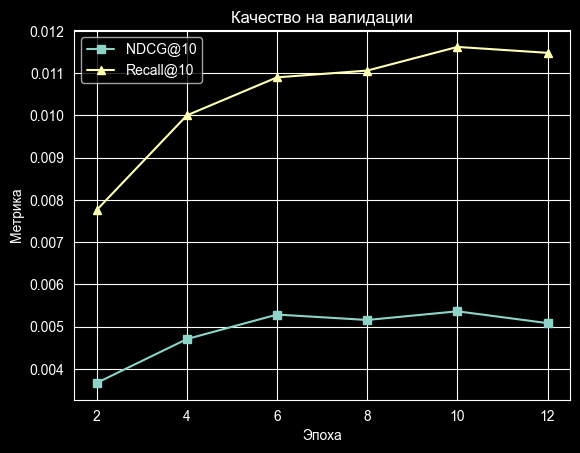

Лучшая NDCG@10: 0.0054
Лучшая Recall@10: 0.0116


In [17]:
validate_epochs = [e for e, v in zip(history['epoch'], history['validate_ndcg']) if v is not None]
validate_ndcg_clean = [v for v in history['validate_ndcg'] if v is not None]
validate_recall_clean = [v for v in history['validate_recall'] if v is not None]

plt.figure()
plt.plot(validate_epochs, validate_ndcg_clean, marker='s', label='NDCG@10')
plt.plot(validate_epochs, validate_recall_clean, marker='^', label='Recall@10')
plt.xlabel('Эпоха')
plt.ylabel('Метрика')
plt.title('Качество на валидации')
plt.legend()
plt.grid(True)
plt.show()

print(f'Лучшая NDCG@10: {max(validate_ndcg_clean):.4f}')
print(f'Лучшая Recall@10: {max(validate_recall_clean):.4f}')

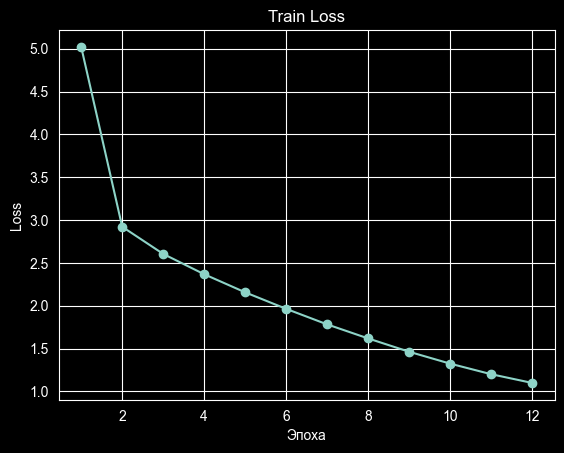

In [18]:
plt.figure()
plt.plot(history['epoch'], history['train_loss'], marker='o')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Train Loss')
plt.grid(True)
plt.show()